In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Activation
from keras.datasets.mnist import load_data

import tensorflow as tf
import matplotlib.pyplot as plt

import json
import os
import shutil
import random
import cv2
import pandas as pd
from matplotlib import pyplot as plt

from matplotlib.ticker import MultipleLocator, FormatStrFormatter

plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["image.cmap"] = "gray"




In [2]:
KAGGLE_PATH = "/root/.kaggle"
if os.path.exists(KAGGLE_PATH):
  !rm -r "$KAGGLE_PATH"

!mkdir "$KAGGLE_PATH"
!touch "$KAGGLE_PATH/kaggle.json"

# https://www.kaggle.com/
api_token = {"username":"Colab_Keras","key":"KGAT_6c5e3427714f0b3f5fe56de3de7aa623"}

with open(KAGGLE_PATH+'/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lubaroli/notmnist")

print("Path to dataset files:", path)

100%|██████████| 8.07M/8.07M [00:00<00:00, 144MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/lubaroli/notmnist/versions/1


In [4]:
SEED_VALUE = 42

# Fix seed to make training deterministic.
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [14]:
import tarfile

# Construct the full path to the NotMNIST_Small.tar.gz file
# Corrected filename: changed 'NotMNIST_Small.tar.gz' to 'notMNIST_small.tar.gz' to match actual file casing.
archive_file_path = os.path.join(path, "notMNIST_small.tar.gz")

# Print the contents of the downloaded directory to debug the missing file
print(f"Contents of the downloaded directory '{path}':")
!ls -F "{path}"

# Create a directory to extract the contents
extracted_dir = os.path.join(path, "NotMNIST_small_extracted")
os.makedirs(extracted_dir, exist_ok=True)

# Extract the tar.gz file
# This part might be redundant if kagglehub.dataset_download already extracted it.
# We need to verify the file structure first.
with tarfile.open(archive_file_path, "r:gz") as tar:
    tar.extractall(path=extracted_dir)

print(f"Dataset extracted to: {extracted_dir}")

Contents of the downloaded directory '/root/.cache/kagglehub/datasets/lubaroli/notmnist/versions/1':
NotMNIST_small_extracted/  NotMNIST_Small_extracted/  notMNIST_small.tar.gz


/tmp/ipykernel_339/2040328489.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extracted_dir)


Dataset extracted to: /root/.cache/kagglehub/datasets/lubaroli/notmnist/versions/1/NotMNIST_small_extracted


In [16]:
def load_notmnist_data(data_dir):
    data = []
    labels = []
    # The NotMNIST dataset has subdirectories named A, B, C, etc.
    # corresponding to the classes.
    for i, class_name in enumerate(sorted(os.listdir(data_dir))):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)
                try:
                    # Read image as grayscale, normalize, and reshape
                    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                    if image is not None:
                        image = image / 255.0 # Normalize pixel values to [0, 1]
                        image = image.reshape(28, 28, 1) # Reshape for Keras input
                        data.append(image)
                        labels.append(i)
                    else:
                        print(f"Warning: Could not read image {image_path}")
                except Exception as e:
                    print(f"Error loading image {image_path}: {e}")

    return np.array(data), np.array(labels)

# Load the entire dataset
# The actual extracted data is one level deeper, e.g., /root/.cache/kagglehub/.../NotMNIST_small_extracted/notMNIST_small
# We need to find the correct subdirectory containing A, B, C, etc.

# Let's inspect the extracted_dir first to find the actual data root.
# The 'ls -F' output from the previous cell showed 'NotMNIST_small_extracted/' and 'NotMNIST_Small_extracted/'.
# Let's assume the correct one for the actual image data is 'notMNIST_small' inside one of these.
# Based on common dataset structures, it's likely a folder named 'notMNIST_small' within 'NotMNIST_small_extracted'

data_root = os.path.join(extracted_dir, 'notMNIST_small')

# Verify if the data_root exists and contains class directories
if not os.path.exists(data_root):
    # If not, it might be directly in extracted_dir if the tar file extracted directly there.
    data_root = extracted_dir

print(f"Loading data from: {data_root}")

X_all, y_all = load_notmnist_data(data_root)

# Split the data into training, validation, and test sets
# Assuming a 60-20-20 split for simplicity, adjust as needed

# First, shuffle the data
indices = np.arange(len(X_all))
np.random.shuffle(indices)
X_all = X_all[indices]
y_all = y_all[indices]

# Calculate split points
total_samples = len(X_all)
train_split = int(0.6 * total_samples)
valid_split = int(0.8 * total_samples)

X_train = X_all[:train_split]
y_train = y_all[:train_split]

X_valid = X_all[train_split:valid_split]
y_valid = y_all[train_split:valid_split]

X_test = X_all[valid_split:]
y_test = y_all[valid_split:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"y_valid shape: {y_valid.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Loading data from: /root/.cache/kagglehub/datasets/lubaroli/notmnist/versions/1/NotMNIST_small_extracted/notMNIST_small
X_train shape: (11234, 28, 28, 1)
y_train shape: (11234,)
X_valid shape: (3745, 28, 28, 1)
y_valid shape: (3745,)
X_test shape: (3745, 28, 28, 1)
y_test shape: (3745,)


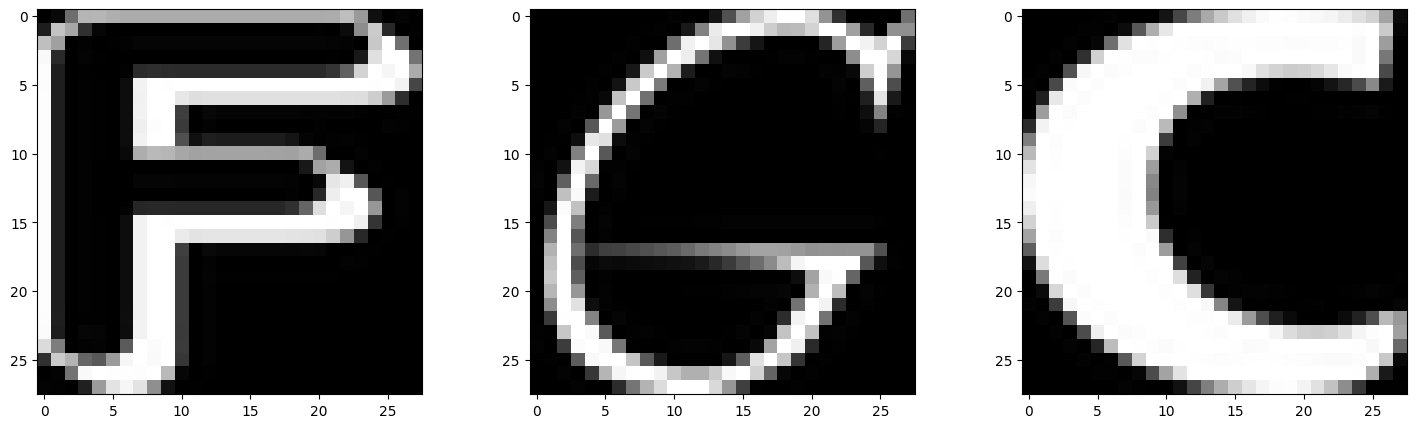

In [17]:
plt.figure(figsize=(18, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.axis(True)
    plt.imshow(X_train[i], cmap="gray")
    plt.subplots_adjust(wspace=0.2, hspace=0.2)

In [18]:
X_train = X_train.reshape((X_train.shape[0], 28 * 28))
X_train = X_train.astype("float32") / 255

X_test = X_test.reshape((X_test.shape[0], 28 * 28))
X_test = X_test.astype("float32") / 255

X_valid = X_valid.reshape((X_valid.shape[0], 28 * 28))
X_valid = X_valid.astype("float32") / 255

In [21]:
# The data has already been loaded and split into X_train, y_train, etc., in a previous cell.
# data_root is a string, not an object with a .load_data() method.
# We can directly inspect y_train.
print(y_train[0:9])

y_train_onehot = to_categorical(y_train[0:9])
print(y_train_onehot)

[5 6 2 6 3 1 0 5 6]
[[0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1.]]


In [22]:
# Convert integer labels to one-hot encoded vectors.
y_train = to_categorical(y_train)
y_valid = to_categorical(y_valid)
y_test  = to_categorical(y_test)

In [24]:
 #Instantiate the model.
model = tf.keras.Sequential()

# Build the model.
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10,  activation="softmax"))

# Display the model summary.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer="rmsprop",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [26]:
training_results = model.fit(X_train,
                             y_train,
                             epochs=21,
                             batch_size=64,
                             validation_data=(X_valid, y_valid));

Epoch 1/21
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1891 - loss: 2.2868 - val_accuracy: 0.3442 - val_loss: 2.0543
Epoch 2/21
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4438 - loss: 1.8644 - val_accuracy: 0.6481 - val_loss: 1.3400
Epoch 3/21
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7198 - loss: 1.1838 - val_accuracy: 0.7618 - val_loss: 0.9050
Epoch 4/21
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7939 - loss: 0.8362 - val_accuracy: 0.7925 - val_loss: 0.7634
Epoch 5/21
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8155 - loss: 0.7152 - val_accuracy: 0.8144 - val_loss: 0.6915
Epoch 6/21
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8353 - loss: 0.6464 - val_accuracy: 0.8312 - val_loss: 0.6392
Epoch 7/21
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8502 - loss: 0.5938 - val_accuracy: 0.8422 - val_loss: 0.5977
Epoch 8/21
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8625 - loss: 0.5518 - val_accuracy: 0.

In [27]:
def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None):

    fig, ax = plt.subplots(figsize=(15, 4))

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, 20])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)
    plt.show()
    plt.close()

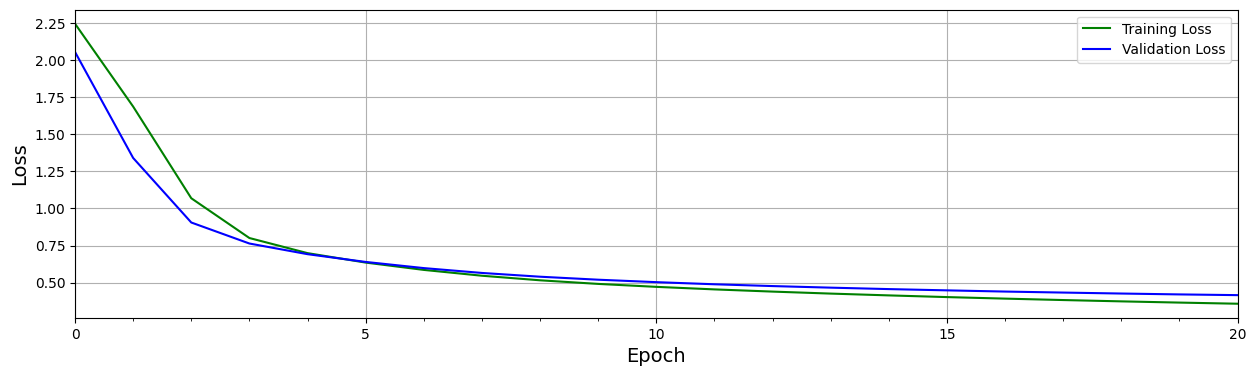

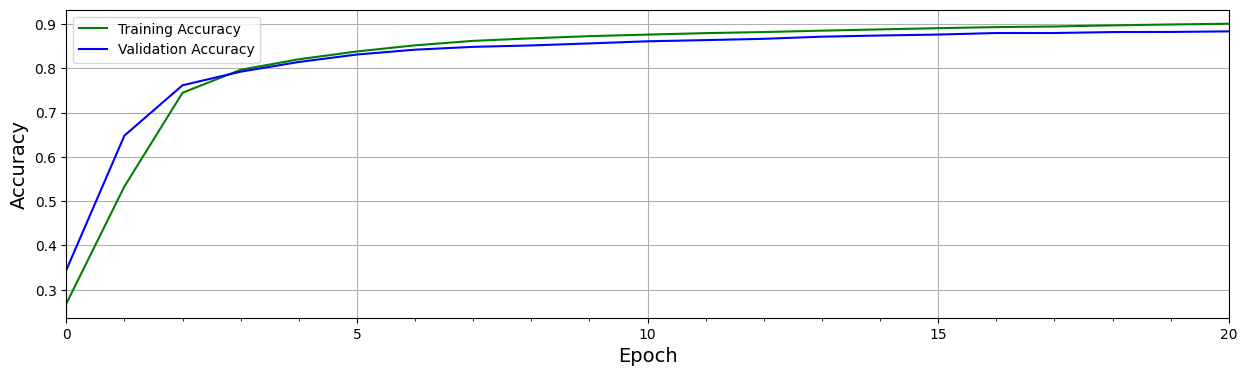

In [29]:
# Retrieve training results.
train_loss = training_results.history["loss"]
train_acc  = training_results.history["accuracy"]
valid_loss = training_results.history["val_loss"]
valid_acc  = training_results.history["val_accuracy"]

plot_results(
    [train_loss, valid_loss],
    ylabel="Loss",
    metric_name=["Training Loss", "Validation Loss"],
    color=["g", "b"],
)

plot_results(
    [train_acc, valid_acc],
    ylabel="Accuracy",
    metric_name=["Training Accuracy", "Validation Accuracy"],
    color=["g", "b"],
)

In [30]:
predictions = model.predict(X_test)
index = 0  # up to 9999
print("Ground truth for test digit: ", y_test[index])
print("\n")
print("Predictions for each class:\n")
for i in range(10):
    print("digit:", i, " probability: ", predictions[index][i])

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Ground truth for test digit:  [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


Predictions for each class:

digit: 0  probability:  1.7803052e-06
digit: 1  probability:  0.0002890341
digit: 2  probability:  0.89539963
digit: 3  probability:  0.00036506163
digit: 4  probability:  0.018828165
digit: 5  probability:  0.0006829048
digit: 6  probability:  0.08426167
digit: 7  probability:  7.3327064e-06
digit: 8  probability:  0.00011158677
digit: 9  probability:  5.2788535e-05


In [31]:
# Generate predictions for the test dataset.
predictions = model.predict(X_test)

# For each sample image in the test dataset, select the class label with the highest probability.
predicted_labels = [np.argmax(i) for i in predictions]

118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


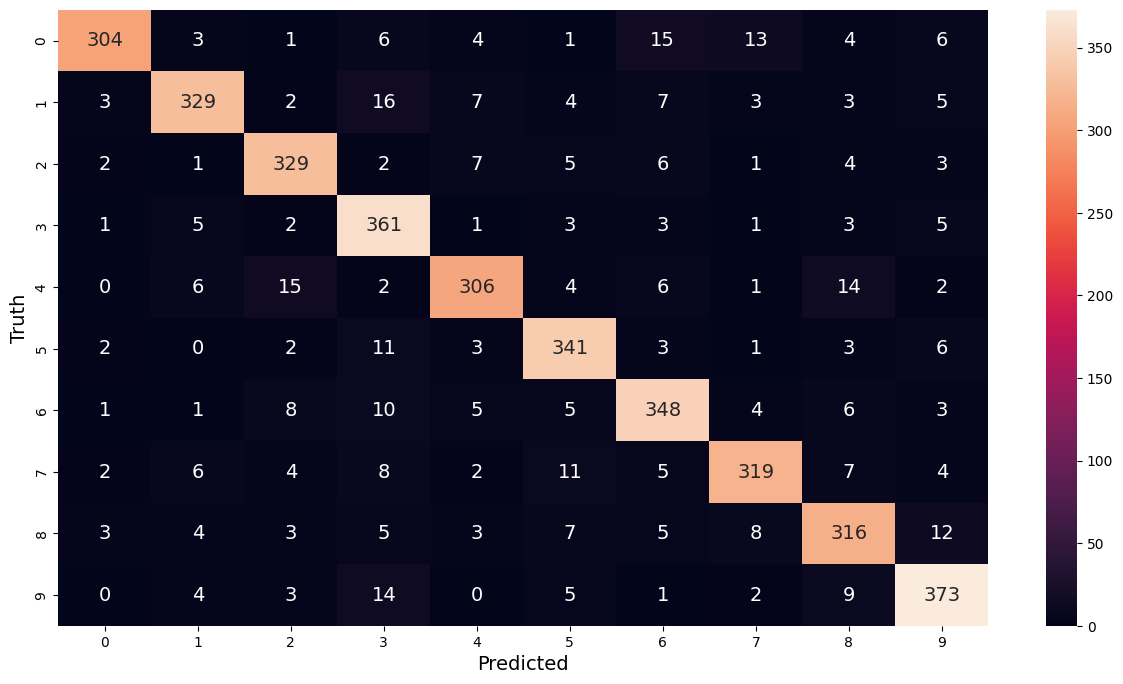

In [32]:
# Convert one-hot encoded labels to integers.
y_test_integer_labels = tf.argmax(y_test, axis=1)

# Generate a confusion matrix for the test dataset.
cm = tf.math.confusion_matrix(labels=y_test_integer_labels, predictions=predicted_labels)

# Plot the confusion matrix as a heatmap.
plt.figure(figsize=[15, 8])
import seaborn as sn

sn.heatmap(cm, annot=True, fmt="d", annot_kws={"size": 14})
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()